# 🏡 AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026
## Capstone Project: End-to-End House Price Prediction System
**Program:** IBM SkillsBuild Academic Internship Program in association with AICTE & BharatCares  
**Domain:** Data Analytics & Machine Learning  
**Project Title:** House Price Prediction & Real Estate Valuation Platform  
**Author:** Data Analytics & AI Intern  

---

### Project Workflow Overview:
1. **Data Ingestion & Understanding**: California Housing Benchmark Dataset (20,640 records).
2. **Exploratory Data Analysis (EDA)**: Statistical distributions, correlation analysis, and geospatial price mapping.
3. **Data Preprocessing & Feature Engineering**: Currency scaling, ratio engineering (`BedroomsPerRoom`), and feature scaling (`StandardScaler`).
4. **Machine Learning Model Development**: Training and tuning 4 candidate algorithms:
   - Baseline Linear Regression
   - L2 Regularized Ridge Regression
   - Random Forest Regressor
   - Gradient Boosting Regressor (Ensemble)
5. **Model Evaluation & Comparative Benchmarking**: Evaluating via $R^2$, MAE, RMSE, and MAPE.
6. **Feature Importance Interpretation**: Quantifying key real estate pricing drivers.
7. **Model Deployment & Export**: Serialization via `joblib` and Streamlit web application integration.


In [1]:
# 1. Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

# Configure visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 10
print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


## 2. Data Ingestion & Exploratory Overview
We load the real-world California Housing dataset from Scikit-Learn. The target feature is converted into standard US Dollar values ($) for real-world real estate appraisal.

In [2]:
# 2. Ingest Dataset
california_data = fetch_california_housing(as_frame=True)
df = california_data.frame.copy()

# Convert target MedHouseVal (in $100k) to true USD ($)
df['Price'] = (df['MedHouseVal'] * 100000).round(2)
df.drop(columns=['MedHouseVal'], inplace=True)

# Derive structural feature
df['BedroomsPerRoom'] = (df['AveBedrms'] / df['AveRooms']).round(4)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 Records:")
df.head()


Dataset Shape: 20640 rows, 10 columns

First 5 Records:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,BedroomsPerRoom
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0,0.1466
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0,0.1558
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0,0.1295
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0,0.1845
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0,0.1721


In [3]:
# Dataset Summary Information and Null Value Verification
print("Dataset Info:")
df.info()
print("\nMissing Value Count per Column:")
print(df.isnull().sum())
print("\nSummary Statistics:")
df.describe().T


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MedInc           20640 non-null  float64
 1   HouseAge         20640 non-null  float64
 2   AveRooms         20640 non-null  float64
 3   AveBedrms        20640 non-null  float64
 4   Population       20640 non-null  float64
 5   AveOccup         20640 non-null  float64
 6   Latitude         20640 non-null  float64
 7   Longitude        20640 non-null  float64
 8   Price            20640 non-null  float64
 9   BedroomsPerRoom  20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB

Missing Value Count per Column:
MedInc             0
HouseAge           0
AveRooms           0
AveBedrms          0
Population         0
AveOccup           0
Latitude           0
Longitude          0
Price              0
BedroomsPerRoom    0
dtype: int64

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
Price,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000
BedroomsPerRoom,20640.0,0.213074,0.058023,0.100000,0.175400,0.203200,0.239800,1.000000


## 3. Exploratory Data Analysis (EDA)
Analyzing data distributions, relationship between median household income and property price, and correlation matrix.

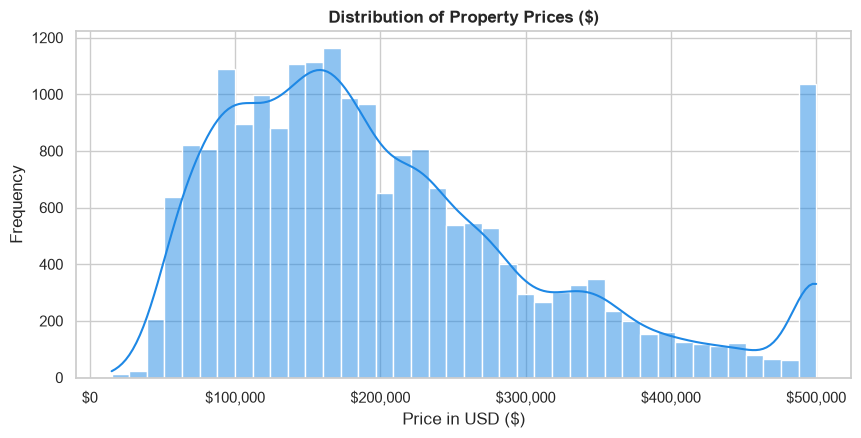

In [4]:
# 3.1 Target Variable Distribution (Price)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(df['Price'], kde=True, color='#1E88E5', bins=40, ax=ax)
ax.set_title('Distribution of Property Prices ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Price in USD ($)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter('${x:,.0f}')
plt.show()


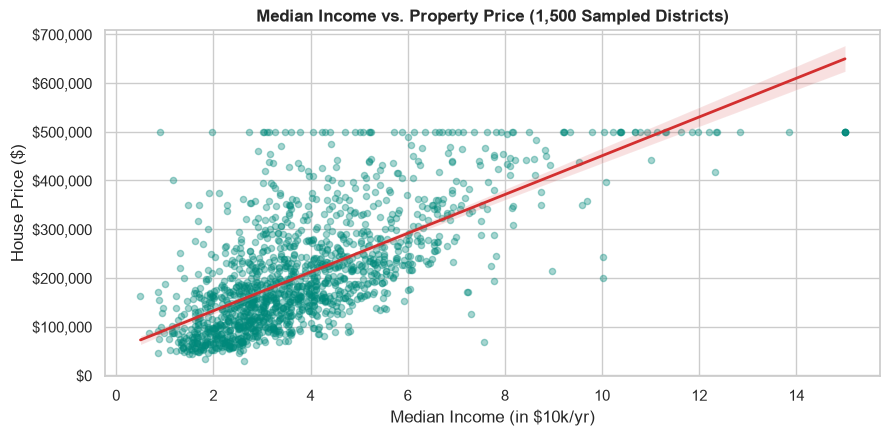

In [5]:
# 3.2 Median Income vs. House Price Scatter with Linear Fit
fig, ax = plt.subplots(figsize=(10, 4.5))
sample_df = df.sample(n=1500, random_state=42)
sns.regplot(data=sample_df, x='MedInc', y='Price',
            scatter_kws={'alpha': 0.35, 'color': '#00897B', 's': 20},
            line_kws={'color': '#D32F2F', 'linewidth': 2}, ax=ax)
ax.set_title('Median Income vs. Property Price (1,500 Sampled Districts)', fontsize=12, fontweight='bold')
ax.set_xlabel('Median Income (in $10k/yr)')
ax.set_ylabel('House Price ($)')
ax.yaxis.set_major_formatter('${x:,.0f}')
plt.show()


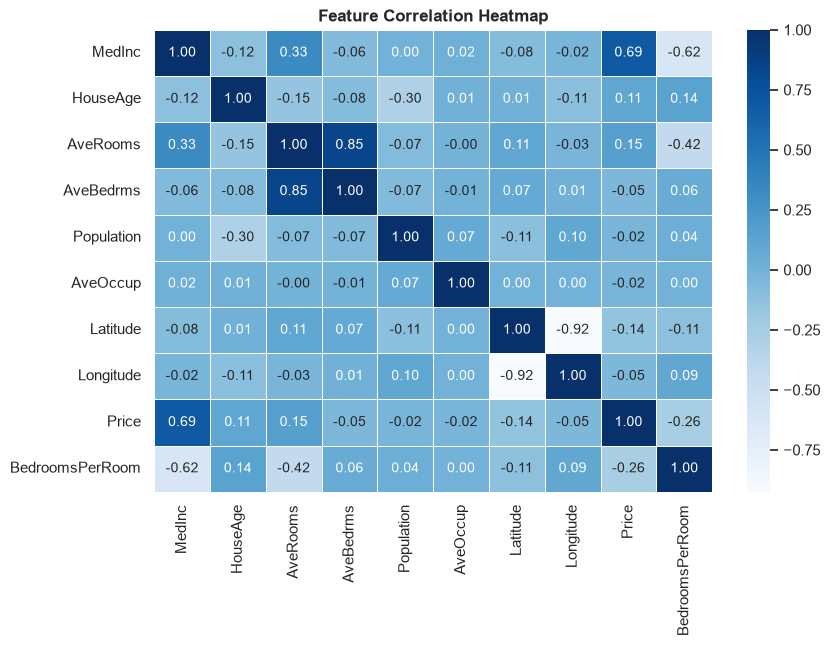

In [6]:
# 3.3 Correlation Matrix Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.show()


## 4. Feature Preprocessing, Scaling & Train-Test Split
Splitting dataset into 80% training and 20% testing sets, followed by Standard Feature Scaling.

In [7]:
# Define Features and Target
feature_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'BedroomsPerRoom']
target_col = 'Price'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training set: {X_train.shape[0]} samples | Testing set: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set: 16512 samples | Testing set: 4128 samples


## 5. Machine Learning Models Training & Benchmarking
We train 4 candidate regression models and evaluate $R^2$, MAE, RMSE, and MAPE.

In [8]:
# Initialize Candidate Algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=120, max_depth=5, learning_rate=0.1, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds) * 100
    
    trained_models[name] = model
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
results_df


,Model,R2 Score,MAE ($),RMSE ($),MAPE (%)
3,Gradient Boosting Regressor,0.8193,32586.08,48662.08,18.98
2,Random Forest Regressor,0.8027,33122.47,50853.16,19.14
1,Ridge Regression,0.5942,52605.18,72920.27,31.64
0,Linear Regression,0.5942,52606.21,72920.65,31.64


C:\Users\asimk\AppData\Local\Temp\ipykernel_16292\170920640.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 Score', palette='Blues_r', ax=ax1)
C:\Users\asimk\AppData\Local\Temp\ipykernel_16292\170920640.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha='right')
C:\Users\asimk\AppData\Local\Temp\ipykernel_16292\170920640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='MAE ($)', palette='Greens_r', ax=ax2)
C:\Users\asimk\AppData\Local\Temp\i

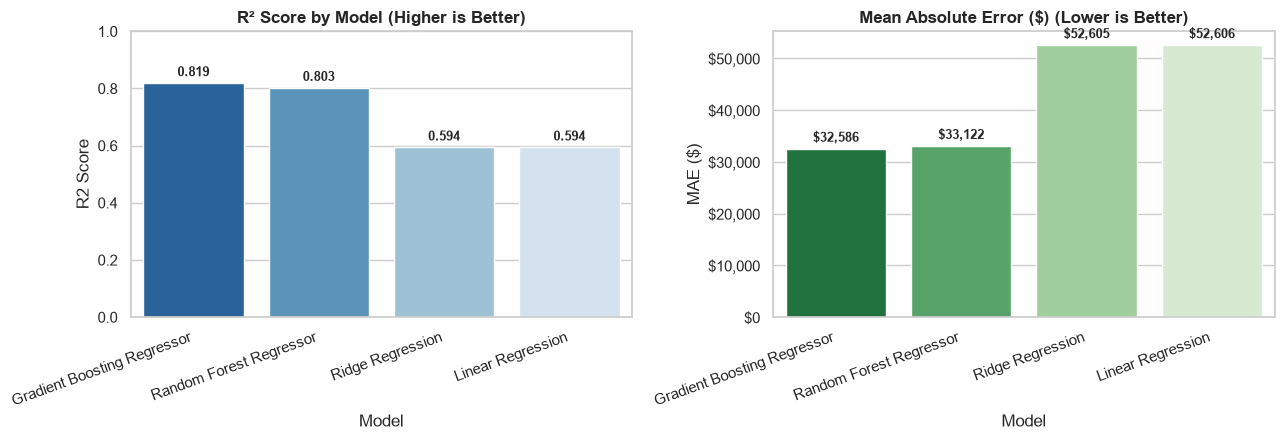

In [9]:
# Model Performance Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=results_df, x='Model', y='R2 Score', palette='Blues_r', ax=ax1)
ax1.set_title('R² Score by Model (Higher is Better)', fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha='right')
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

sns.barplot(data=results_df, x='Model', y='MAE ($)', palette='Greens_r', ax=ax2)
ax2.set_title('Mean Absolute Error ($) (Lower is Better)', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha='right')
ax2.yaxis.set_major_formatter('${x:,.0f}')
for p in ax2.patches:
    ax2.annotate(f"${p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


## 6. Feature Importance Interpretation
Extracting feature importance weights from the best performing Gradient Boosting model to reveal what factors most impact real estate prices.

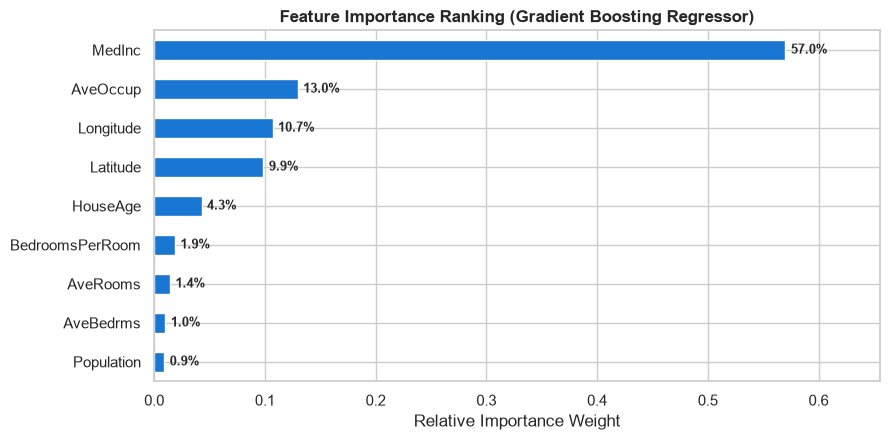

In [10]:
best_model = trained_models["Gradient Boosting Regressor"]
feat_imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(9, 4.5))
feat_imp.plot(kind='barh', color='#1976D2')
plt.title('Feature Importance Ranking (Gradient Boosting Regressor)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Weight')
for idx, val in enumerate(feat_imp):
    plt.text(val + 0.005, idx, f"{val*100:.1f}%", va='center', fontweight='bold', fontsize=9)
plt.xlim(0, feat_imp.max() * 1.15)
plt.tight_layout()
plt.show()


## 7. Model Serialization & Production Inference Test
Saving the fitted model and scaler with `joblib`, and testing inference with a simulated property.

In [11]:
# Save trained artifacts
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
print("✓ Model and Scaler successfully serialized into models/ directory.")

# Test Inference
sample_property = {
    'MedInc': 8.5,           # $85,000 median annual household income
    'HouseAge': 20.0,        # 20 years old
    'AveRooms': 6.8,         # 6.8 average rooms
    'AveBedrms': 1.1,        # 1.1 bedrooms
    'Population': 900.0,     # 900 district residents
    'AveOccup': 2.7,         # 2.7 people per house
    'Latitude': 37.77,       # Bay Area Latitude
    'Longitude': -122.42,    # Bay Area Longitude
    'BedroomsPerRoom': 1.1 / 6.8
}

input_vector = pd.DataFrame([[sample_property[col] for col in feature_cols]], columns=feature_cols)
scaled_vector = scaler.transform(input_vector)
predicted_price = float(best_model.predict(scaled_vector)[0])
mae = results_df[results_df['Model'] == 'Gradient Boosting Regressor']['MAE ($)'].values[0]

print("=" * 55)
print("🏡 INFERENCE VALUATION RESULT:")
print(f"Predicted Property Price: ${predicted_price:,.2f}")
print(f"Valuation Range (±MAE) : ${predicted_price - mae:,.2f} to ${predicted_price + mae:,.2f}")
print("=" * 55)


✓ Model and Scaler successfully serialized into models/ directory.
🏡 INFERENCE VALUATION RESULT:
Predicted Property Price: $448,967.20
Valuation Range (±MAE) : $416,381.12 to $481,553.28


## 8. Web Application Frontend Integration
The model has been deployed into a reactive Python **Streamlit** web application (`app.py`), featuring:
1. **Interactive Valuation Sliders**: Instant house price calculation with location presets.
2. **Exploratory Data Analysis Dashboard**: Histograms, scatter plots, and correlation matrix.
3. **California Geospatial Map**: Interactive map with price filtering slider.
4. **Model Benchmarks & Feature Importance**: Comparison table and bar charts.
5. **Batch CSV Processing**: Upload CSV files for mass appraisal and export results.

**Launch Command:**
```bash
python -m streamlit run house_price_prediction/app.py
```
